# 📓 Practice quiz: Classification with Logistic Regression

---

# Question 1

**Which is an example of a classification task?**

- [ ] Based on the size of each tumor, determine if each tumor is malignant (cancerous) or not.
- [ ] Based on a patient's blood pressure, determine how much blood pressure medication (a dosage measured in milligrams) the patient should be prescribed.
- [ ] Based on a patient's age and blood pressure, determine how much blood pressure medication (measured in milligrams) the patient should be prescribed.

---

### ✅ Correct Answer

**Option 1:** "Based on the size of each tumor, determine if each tumor is malignant (cancerous) or not."

---

### 📖 Explanation of Correct Answer

This is a **classification task** because the output is a **category** (malignant or not malignant), not a continuous number.

**Key characteristics of classification:**
- The output variable \( y \) takes on **discrete values** (in this case, 0 for "not malignant" and 1 for "malignant")
- We're assigning each input to a **class or category**
- There are a **finite number of possible outputs** (here, exactly 2)

In the tumor example, regardless of tumor size, we're only ever predicting one of two possible answers: "cancerous" or "not cancerous". This is the defining feature of **binary classification**.

---

### ❌ Why the Other Options Are Incorrect

**Option 2:** "Based on a patient's blood pressure, determine how much blood pressure medication (a dosage measured in milligrams) the patient should be prescribed."

This is a **regression task**, not classification. The output is a **continuous numerical value** (milligrams of medication). The dosage could be any number within a range (e.g., 5 mg, 5.5 mg, 10 mg, etc.), not just a few discrete categories.

**Option 3:** "Based on a patient's age and blood pressure, determine how much blood pressure medication (measured in milligrams) the patient should be prescribed."

This is **also a regression task** for the same reason as Option 2. Even though we're using more input features (age and blood pressure), the output is still a continuous quantity (milligrams), making it a regression problem.

---

### 🌍 Real-World Examples

| **Task Type** | **Examples** |
|---------------|--------------|
| **Classification** | • **Email spam detection** (spam or not spam)<br>• **Credit card fraud detection** (fraudulent or legitimate)<br>• **Image recognition** (cat, dog, bird, etc.)<br>• **Medical diagnosis** (disease present or absent)<br>• **Customer churn prediction** (will leave or stay) |
| **Regression** | • **House price prediction** (price in rupees)<br>• **Temperature forecasting** (degrees Celsius)<br>• **Stock market prediction** (price value)<br>• **Sales forecasting** (units sold)<br>• **Insurance risk assessment** (risk score from 0 to 100) |

---



---

# Question 2

Recall the sigmoid function is \( $g(z) = \frac{1}{1+e^{-z}}$ \)

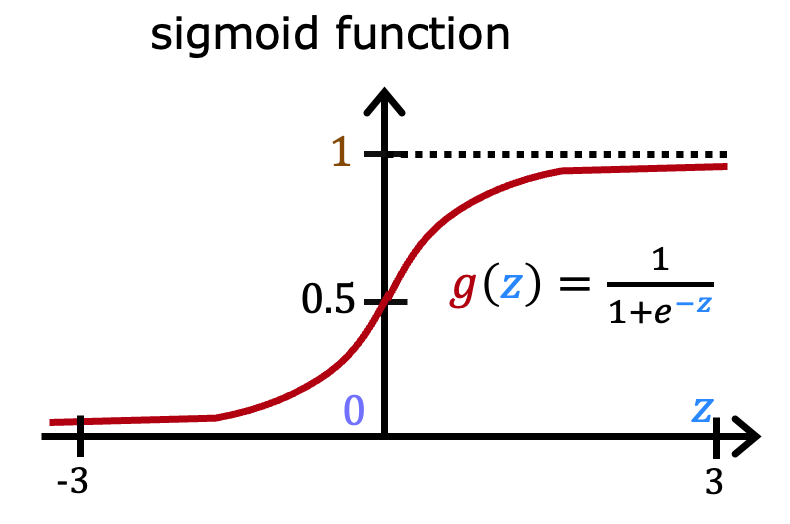

If \( $z$ \) is a large positive number, then:

- [ ] \( $g(z)$ \) is near one (1)
- [ ] \( $g(z)$ \) is near negative one (-1)
- [ ] \( $g(z)$ \) will be near zero (0)
- [ ] \( $g(z)$ \) will be near 0.5

---

### ✅ Correct Answer

**Option 1:** \( $g(z)$ \) is near one (1)

---

### 📖 Explanation of Correct Answer

The sigmoid function \( $g(z) = \frac{1}{1+e^{-z}}$ \) has the following properties:

| **When z is...** | **$e^{-z}$ becomes...** | **Denominator becomes...** | **g(z) approaches...** |
|-------------------|------------------------|----------------------------|------------------------|
| Large positive | Very small (near 0) | 1 + (near 0) ≈ 1 | **1** |
| Zero | $e^0$ = 1 | 1 + 1 = 2 | **0.5** |
| Large negative | Very large | 1 + huge number ≈ huge | **0** |

**Mathematical intuition:**
- If \( $z$ = 100 \), then \( $e^{-100}$ \) is an extremely tiny number (approximately \( $3.7 \times 10^{-44}$ \))
- So \( $g(100) = \frac{1}{1 + \text{tiny}} \approx \frac{1}{1} = 1$ \)

This is why the sigmoid function is perfect for **probability estimation** in classification problems:
- Large positive z → very confident the example belongs to class 1
- Large negative z → very confident the example belongs to class 0

---

### ❌ Why the Other Options Are Incorrect

| **Option** | **Why It's Incorrect** |
|------------|------------------------|
| **Option 2:** near -1 | The sigmoid function **never outputs negative values**. Its range is strictly (0, 1). |
| **Option 3:** near 0 | This happens when z is a **large negative** number, not large positive. |
| **Option 4:** near 0.5 | This only happens when **z is exactly 0**, not when z is large. |

---

### 📊 Visualizing the Sigmoid Function

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7611 (\N{MODIFIER LETTER SMALL Z}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


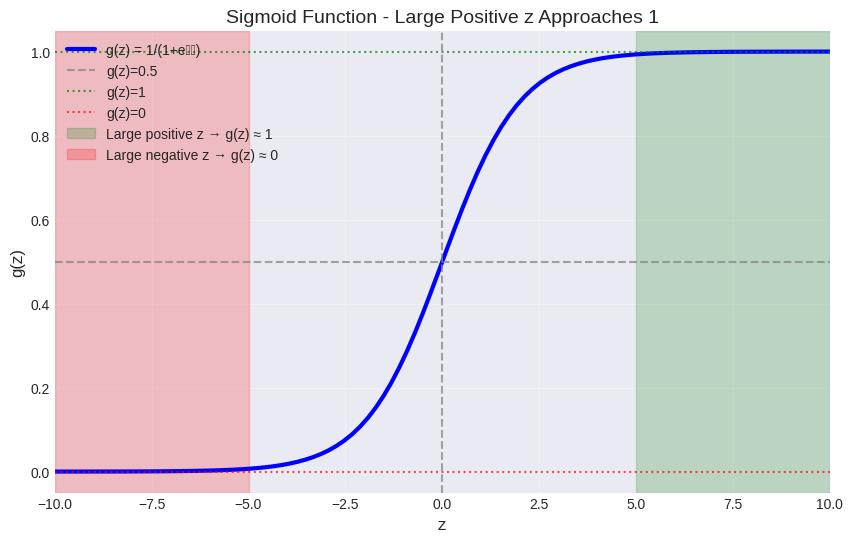

g(5) = 0.993307
g(10) = 0.9999546021
g(100) would be essentially 1 (difference too small to display)


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Generate values
z = np.linspace(-10, 10, 100)
g = 1 / (1 + np.exp(-z))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(z, g, 'b-', linewidth=3, label='g(z) = 1/(1+e⁻ᶻ)')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='g(z)=0.5')
plt.axhline(y=1, color='green', linestyle=':', alpha=0.7, label='g(z)=1')
plt.axhline(y=0, color='red', linestyle=':', alpha=0.7, label='g(z)=0')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)

# Highlight large positive region
plt.axvspan(5, 10, alpha=0.2, color='green', label='Large positive z → g(z) ≈ 1')
plt.axvspan(-10, -5, alpha=0.2, color='red', label='Large negative z → g(z) ≈ 0')

plt.xlabel('z', fontsize=12)
plt.ylabel('g(z)', fontsize=12)
plt.title('Sigmoid Function - Large Positive z Approaches 1', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(-10, 10)
plt.ylim(-0.05, 1.05)
plt.show()

print(f"g(5) = {1/(1+np.exp(-5)):.6f}")
print(f"g(10) = {1/(1+np.exp(-10)):.10f}")
print(f"g(100) would be essentially 1 (difference too small to display)")

---

# Question 3

**True/False?** No matter what features you use (including if you use polynomial features), the decision boundary learned by logistic regression will be a linear decision boundary.

- [ ] False
- [ ] True

---

### ✅ Correct Answer

**False**

---

### 📖 Explanation

The statement is **false** because **logistic regression can learn non-linear decision boundaries** when polynomial features are used.

**Key insight:** The decision boundary is determined by the equation:
\[ $\vec{w} \cdot \vec{x} + b = 0$ \]

While this is **linear in the parameters** (\( $\vec{w}$ \) and \( $b$ \)), it can be **non-linear in the original input features** if we create polynomial features.

---

### 🧮 Mathematical Explanation

**Case 1: Using original features only**
- If \( $z = w_1x_1 + w_2x_2 + b$ \), the decision boundary \( $z = 0$ \) is a straight line
- Example: \( $x_1 + x_2 - 3 = 0$ \) is a line

**Case 2: Using polynomial features**
- If we create features like \( $x_1^2, x_2^2, x_1x_2$ \), then:
  \[ $z = w_1x_1 + w_2x_2 + w_3x_1^2 + w_4x_2^2 + w_5x_1x_2 + b$ \]
- Setting \( $z = 0$ \) can represent:
  - Circles (\( $x_1^2 + x_2^2 = r^2$ \))
  - Ellipses
  - Parabolas
  - And other complex curves

---

### 📊 Visual Examples

/tmp/ipykernel_382/1734952722.py:40: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_382/1734952722.py:40: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


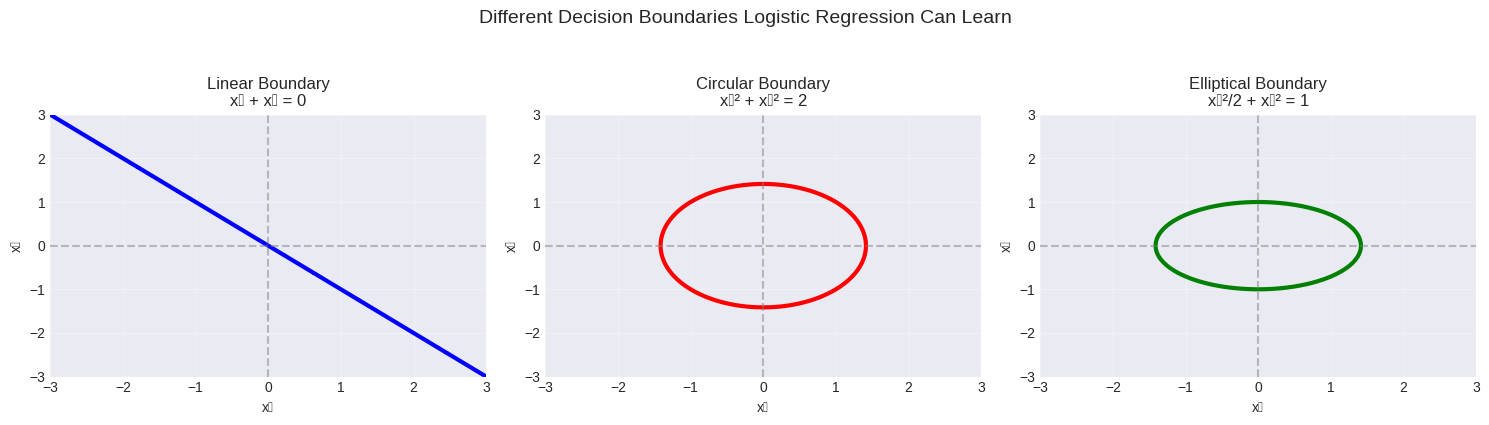

With polynomial features, logistic regression can learn:
✓ Circles
✓ Ellipses
✓ Parabolas
✓ Hyperbolas
✓ And many other complex shapes


In [11]:
# Demonstrate non-linear decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Create mesh grid
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

# Example 1: Linear decision boundary
Z1 = X + Y  # w₁x₁ + w₂x₂ = 0
axes[0].contour(X, Y, Z1, levels=[0], colors='blue', linewidths=3)
axes[0].set_title('Linear Boundary\nx₁ + x₂ = 0', fontsize=12)
axes[0].set_xlabel('x₁')
axes[0].set_ylabel('x₂')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Example 2: Circular decision boundary (using polynomial features)
Z2 = X**2 + Y**2 - 2  # x₁² + x₂² = 2
axes[1].contour(X, Y, Z2, levels=[0], colors='red', linewidths=3)
axes[1].set_title('Circular Boundary\nx₁² + x₂² = 2', fontsize=12)
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Example 3: Elliptical decision boundary
Z3 = X**2/2 + Y**2 - 1  # x₁²/2 + x₂² = 1
axes[2].contour(X, Y, Z3, levels=[0], colors='green', linewidths=3)
axes[2].set_title('Elliptical Boundary\nx₁²/2 + x₂² = 1', fontsize=12)
axes[2].set_xlabel('x₁')
axes[2].set_ylabel('x₂')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Different Decision Boundaries Logistic Regression Can Learn', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("With polynomial features, logistic regression can learn:")
print("✓ Circles")
print("✓ Ellipses")
print("✓ Parabolas")
print("✓ Hyperbolas")
print("✓ And many other complex shapes")

---

### 🎯 Common Misconception

Many beginners think "logistic regression" means the decision boundary must be linear. This is incorrect!

- **"Regression" in the name** is historical and misleading
- **Linear in parameters** ≠ linear in features
- By engineering features cleverly, we can model **highly non-linear relationships**

---

---

# Question 4

A cat photo classification model predicts 1 if it's a cat, and 0 if it's not a cat. For a particular photograph, the logistic regression model outputs \( $g(z)$ \) (a number between 0 and 1). Which of these would be a reasonable criteria to decide whether to predict if it's a cat?

- [ ] Predict it is a cat if \( $g(z) \geq 0.5$ \)
- [ ] Predict it is a cat if \( $g(z) < 0.5$ \)
- [ ] Predict it is a cat if \( $g(z) = 0.5$ \)
- [ ] Predict it is a cat if \( $g(z) < 0.7$ \)

---

### ✅ Correct Answer

**Option 1:** Predict it is a cat if \( $g(z) \geq 0.5$ \)

---

### 📖 Explanation

In logistic regression, \( $g(z)$ \) outputs a **probability** that the example belongs to class 1 (in this case, "cat").

The **default and most reasonable threshold** is 0.5 because:
- \( $g(z) \geq 0.5$ \) means the model thinks there's at least a 50% chance it's a cat
- At \( $g(z) = 0.5$ \), the model is exactly neutral (equal probability for both classes)
- This threshold naturally separates "more likely to be cat" from "more likely to be not cat"

**Mathematically:**
$$
\text{Prediction =}
\begin{cases}
1 \text{ (cat)} & \text{if } g(z) \geq 0.5 \\
0 \text{ (not cat)} & \text{if } g(z) < 0.5
\end{cases}
$$

This aligns with the decision boundary concept: \( $g(z)$ = 0.5 \) occurs when \( $z = 0$ \), which is our decision boundary.

---

### ❌ Why the Other Options Are Incorrect

| **Option** | **Why It's Unreasonable** |
|------------|---------------------------|
| **Option 2:** \( g(z) < 0.5 \) | This would predict "cat" when probability is **below 50%** - completely opposite of what we want! |
| **Option 3:** \( g(z) = 0.5 \) | This would only predict "cat" when the model is **exactly uncertain**. Since probability is continuous, this would almost never happen. |
| **Option 4:** \( g(z) < 0.7 \) | This is a **valid alternative threshold** (more conservative), but it's not the default or most reasonable. It would predict "cat" for probabilities below 70%, which is counterintuitive. |

---

### 🎯 When Would You Use Different Thresholds?

While 0.5 is the default, real-world applications often use different thresholds:

| **Scenario** | **Threshold** | **Why** |
|--------------|---------------|---------|
| **Medical diagnosis** (e.g., cancer detection) | Lower (e.g., 0.3) | Better to flag more cases for further testing (false positives are cheaper than false negatives) |
| **Spam detection** | Higher (e.g., 0.8) | Better to let some spam through than to block important emails |
| **Cat photo classifier** | 0.5 | Balanced approach, no strong preference for either error type |

---

### 📊 Visualizing Different Thresholds

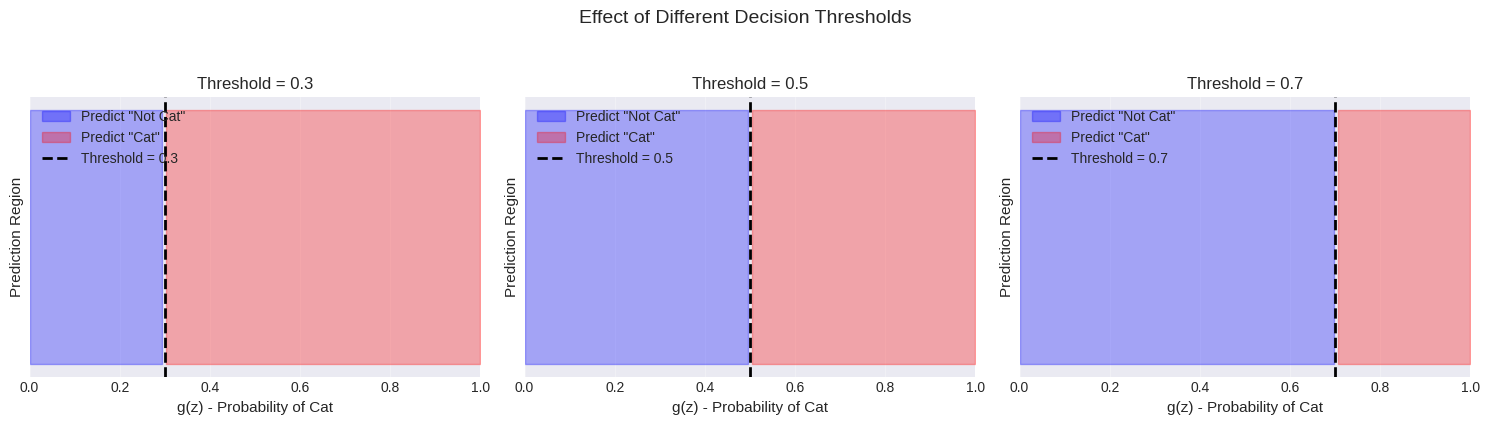

At threshold = 0.5, we have a balanced approach.
At threshold = 0.3, we're more aggressive about predicting cats (lower bar).
At threshold = 0.7, we're more conservative about predicting cats (higher bar).


In [12]:
# Show impact of different thresholds
probabilities = np.linspace(0, 1, 100)
thresholds = [0.3, 0.5, 0.7]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, thresh in enumerate(thresholds):
    predictions = (probabilities >= thresh).astype(int)

    axes[i].fill_between(probabilities, 0, 1, where=(probabilities < thresh),
                         color='blue', alpha=0.3, label='Predict "Not Cat"')
    axes[i].fill_between(probabilities, 0, 1, where=(probabilities >= thresh),
                         color='red', alpha=0.3, label='Predict "Cat"')
    axes[i].axvline(x=thresh, color='black', linewidth=2, linestyle='--',
                    label=f'Threshold = {thresh}')

    axes[i].set_xlabel('g(z) - Probability of Cat', fontsize=11)
    axes[i].set_ylabel('Prediction Region', fontsize=11)
    axes[i].set_title(f'Threshold = {thresh}', fontsize=12)
    axes[i].set_yticks([])
    axes[i].legend(loc='upper left')
    axes[i].set_xlim(0, 1)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Effect of Different Decision Thresholds', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("At threshold = 0.5, we have a balanced approach.")
print("At threshold = 0.3, we're more aggressive about predicting cats (lower bar).")
print("At threshold = 0.7, we're more conservative about predicting cats (higher bar).")

# 📝 Summary Table

| **Question** | **Topic** | **Correct Answer** | **Key Takeaway** |
|--------------|-----------|---------------------|------------------|
| 1 | Classification vs Regression | Option 1 | Classification predicts **categories**; regression predicts **continuous numbers** |
| 2 | Sigmoid Function Properties | Option 1 | Large positive z → \( g(z) \approx 1 \) (confident class 1) |
| 3 | Decision Boundaries | False | Logistic regression can learn **non-linear** boundaries with polynomial features |
| 4 | Decision Threshold | Option 1 | Default threshold of 0.5 is reasonable; can be adjusted based on application |

---

